**生成式 AI 使用说明**：在本课程作业中，使用生成式 AI 需要遵守与协作讨论相同的政策。和其他合作者一样，每位学生都必须独立写出自己的解答，不能直接依赖交互输出完成提交内容，并且提交时应说明协作的性质。使用生成式 AI 工具实质性地完成作业中的部分内容，不符合本课程作业精神，也会违反 [Honor Code](https://communitystandards.stanford.edu/policies-and-guidance/honor-code)。

In [ ]:
# This mounts your Google Drive to the Colab VM.
from google.colab import drive
drive.mount('/content/drive')

# TODO: Enter the foldername in your Drive where you have saved the unzipped
# assignment folder, e.g. 'cs231n/assignments/assignment1/'
FOLDERNAME = 'cs231n/assignments/assignment1/'
assert FOLDERNAME is not None, "[!] Enter the foldername."

# Now that we've mounted your Drive, this ensures that
# the Python interpreter of the Colab VM can load
# python files from within it.
import sys
sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))

# This downloads the CIFAR-10 dataset to your Drive
# if it doesn't already exist.
%cd /content/drive/My\ Drive/$FOLDERNAME/cs231n/datasets/
!bash get_datasets.sh
%cd /content/drive/My\ Drive/$FOLDERNAME

# Softmax 分类器练习

*请完成并提交这份 worksheet，包括运行输出，以及 worksheet 之外你修改过的所有辅助代码。更多细节请参考课程网站上的 [assignments page](http://vision.stanford.edu/teaching/cs231n/assignments.html)。*

在本练习中，你将：
    
- 为 Softmax 分类器实现完全向量化的**损失函数**。
- 实现完全向量化的**解析梯度**表达式。
- 使用数值梯度**检查你的实现**。
- 使用验证集**调整学习率和正则化强度**。
- 使用 **SGD 优化**损失函数。
- **可视化**最终学到的权重。


In [2]:
# Run some setup code for this notebook.
import random
import numpy as np
from cs231n.data_utils import load_CIFAR10
import matplotlib.pyplot as plt

# This is a bit of magic to make matplotlib figures appear inline in the
# notebook rather than in a new window.
%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# Some more magic so that the notebook will reload external python modules;
# see http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
%load_ext autoreload
%autoreload 2

## CIFAR-10 数据加载与预处理

In [3]:
# Load the raw CIFAR-10 data.
cifar10_dir = 'cs231n/datasets/cifar-10-batches-py'

# Cleaning up variables to prevent loading data multiple times (which may cause memory issue)
try:
   del X_train, y_train
   del X_test, y_test
   print('Clear previously loaded data.')
except:
   pass

X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

# As a sanity check, we print out the size of the training and test data.
print('Training data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Training data shape:  (50000, 32, 32, 3)
Training labels shape:  (50000,)
Test data shape:  (10000, 32, 32, 3)
Test labels shape:  (10000,)


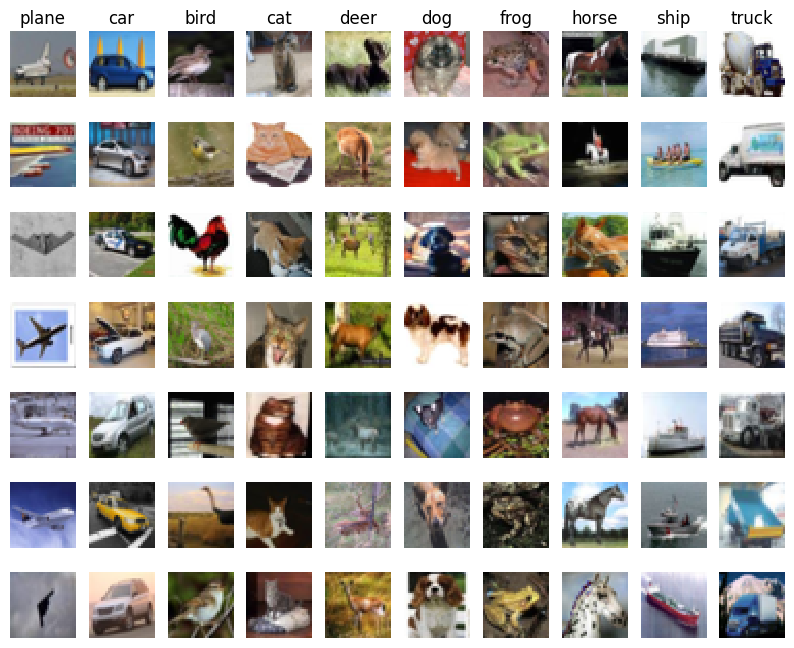

In [4]:
# Visualize some examples from the dataset.
# We show a few examples of training images from each class.
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
num_classes = len(classes)
samples_per_class = 7
for y, cls in enumerate(classes):
    idxs = np.flatnonzero(y_train == y)
    idxs = np.random.choice(idxs, samples_per_class, replace=False)
    for i, idx in enumerate(idxs):
        plt_idx = i * num_classes + y + 1
        plt.subplot(samples_per_class, num_classes, plt_idx)
        plt.imshow(X_train[idx].astype('uint8'))
        plt.axis('off')
        if i == 0:
            plt.title(cls)
plt.show()

In [5]:
# Split the data into train, val, and test sets. In addition we will
# create a small development set as a subset of the training data;
# we can use this for development so our code runs faster.
num_training = 49000
num_validation = 1000
num_test = 1000
num_dev = 500

# Our validation set will be num_validation points from the original
# training set.
mask = range(num_training, num_training + num_validation)
X_val = X_train[mask]
y_val = y_train[mask]

# Our training set will be the first num_train points from the original
# training set.
mask = range(num_training)
X_train = X_train[mask]
y_train = y_train[mask]

# We will also make a development set, which is a small subset of
# the training set.
mask = np.random.choice(num_training, num_dev, replace=False)
X_dev = X_train[mask]
y_dev = y_train[mask]

# We use the first num_test points of the original test set as our
# test set.
mask = range(num_test)
X_test = X_test[mask]
y_test = y_test[mask]

print('Train data shape: ', X_train.shape)
print('Train labels shape: ', y_train.shape)
print('Validation data shape: ', X_val.shape)
print('Validation labels shape: ', y_val.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Train data shape:  (49000, 32, 32, 3)
Train labels shape:  (49000,)
Validation data shape:  (1000, 32, 32, 3)
Validation labels shape:  (1000,)
Test data shape:  (1000, 32, 32, 3)
Test labels shape:  (1000,)


In [6]:
# Preprocessing: reshape the image data into rows
X_train = np.reshape(X_train, (X_train.shape[0], -1))
X_val = np.reshape(X_val, (X_val.shape[0], -1))
X_test = np.reshape(X_test, (X_test.shape[0], -1))
X_dev = np.reshape(X_dev, (X_dev.shape[0], -1))

# As a sanity check, print out the shapes of the data
print('Training data shape: ', X_train.shape)
print('Validation data shape: ', X_val.shape)
print('Test data shape: ', X_test.shape)
print('dev data shape: ', X_dev.shape)

Training data shape:  (49000, 3072)
Validation data shape:  (1000, 3072)
Test data shape:  (1000, 3072)
dev data shape:  (500, 3072)


[130.64189796 135.98173469 132.47391837 130.05569388 135.34804082
 131.75402041 130.96055102 136.14328571 132.47636735 131.48467347]


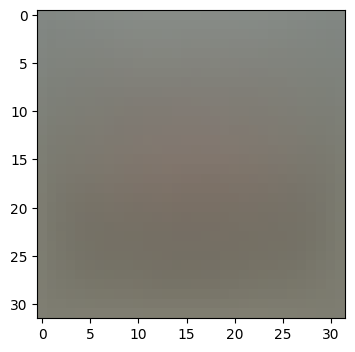

(49000, 3073) (1000, 3073) (1000, 3073) (500, 3073)


In [7]:
# Preprocessing: subtract the mean image
# first: compute the image mean based on the training data
mean_image = np.mean(X_train, axis=0)
print(mean_image[:10]) # print a few of the elements
plt.figure(figsize=(4,4))
plt.imshow(mean_image.reshape((32,32,3)).astype('uint8')) # visualize the mean image
plt.show()

# second: subtract the mean image from train and test data
X_train -= mean_image
X_val -= mean_image
X_test -= mean_image
X_dev -= mean_image

# third: append the bias dimension of ones (i.e. bias trick) so that our classifier
# only has to worry about optimizing a single weight matrix W.
X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
X_val = np.hstack([X_val, np.ones((X_val.shape[0], 1))])
X_test = np.hstack([X_test, np.ones((X_test.shape[0], 1))])
X_dev = np.hstack([X_dev, np.ones((X_dev.shape[0], 1))])

print(X_train.shape, X_val.shape, X_test.shape, X_dev.shape)

## Softmax 分类器

本节的所有代码都将在 `cs231n/classifiers/softmax.py` 中编写。

可以看到，我们已经预先填写了 `softmax_loss_naive` 函数，它使用循环来计算 Softmax 损失函数。

In [8]:
# Evaluate the naive implementation of the loss we provided for you:
from cs231n.classifiers.softmax import softmax_loss_naive
import time

# generate a random Softmax classifier weight matrix of small numbers
W = np.random.randn(3073, 10) * 0.0001

loss, grad = softmax_loss_naive(W, X_dev, y_dev, 0.000005)
print('loss: %f' % (loss, ))

# As a rough sanity check, our loss should be something close to -log(0.1).
print('loss: %f' % loss)
print('sanity check: %f' % (-np.log(0.1)))

loss: 2.338504
loss: 2.338504
sanity check: 2.302585


**行内问题 1**

为什么我们预计损失会接近 $-\log(0.1)$？请简要说明。

$\color{blue}{\textit{你的答案：}}$ *在此填写*



上面函数返回的 `grad` 目前全为零。请推导 Softmax 损失函数的梯度，并在 `softmax_loss_naive` 函数内部直接实现它。将新代码穿插到现有函数中会比较方便。

为了检查梯度是否实现正确，可以用数值方法估计损失函数的梯度，并把数值估计与计算得到的梯度进行比较。我们已经提供了执行这一检查的代码：

In [9]:
# Once you've implemented the gradient, recompute it with the code below
# and gradient check it with the function we provided for you

# Compute the loss and its gradient at W.
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 0.0)

# Numerically compute the gradient along several randomly chosen dimensions, and
# compare them with your analytically computed gradient. The numbers should match
# almost exactly along all dimensions.
from cs231n.gradient_check import grad_check_sparse
f = lambda w: softmax_loss_naive(w, X_dev, y_dev, 0.0)[0]
grad_numerical = grad_check_sparse(f, W, grad)

# do the gradient check once again with regularization turned on
# you didn't forget the regularization gradient did you?
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 5e1)
f = lambda w: softmax_loss_naive(w, X_dev, y_dev, 5e1)[0]
grad_numerical = grad_check_sparse(f, W, grad)

numerical: 1.789899 analytic: 1.789899, relative error: 1.012088e-08
numerical: -2.989274 analytic: -2.989274, relative error: 2.324373e-09
numerical: -3.869411 analytic: -3.869411, relative error: 4.091198e-09
numerical: -4.578809 analytic: -4.578809, relative error: 1.371759e-08
numerical: -2.298604 analytic: -2.298604, relative error: 1.786819e-08
numerical: 1.905782 analytic: 1.905782, relative error: 4.467841e-08
numerical: -1.083628 analytic: -1.083628, relative error: 2.297628e-09
numerical: -0.160058 analytic: -0.160058, relative error: 1.368908e-07
numerical: -0.076295 analytic: -0.076295, relative error: 7.771687e-08
numerical: 1.568031 analytic: 1.568031, relative error: 9.512237e-09
numerical: 0.018439 analytic: 0.018439, relative error: 8.580535e-10
numerical: 3.203718 analytic: 3.203718, relative error: 1.230588e-08
numerical: 1.905851 analytic: 1.905851, relative error: 1.751683e-08
numerical: -0.114397 analytic: -0.114397, relative error: 8.813893e-07
numerical: 0.47565

**行内问题 2**

虽然对 Softmax 损失进行梯度检查通常很可靠，但对 SVM 损失来说，梯度检查中的某个维度偶尔可能无法完全匹配。造成这种差异的原因可能是什么？这是否值得担心？请给出一个一维的简单例子，说明 SVM 损失的梯度检查何时可能失败。改变间隔（margin）会如何影响这种情况发生的频率？

注意，样本 $(x_i, y_i)$ 的 SVM 损失定义为：$$L_i = \sum_{j\ne y_i}\max(0, s_j - s_{y_i} + \Delta)$$，其中 $j$ 遍历正确类别 $y_i$ 之外的所有类别，$s_j$ 表示第 $j$ 类的分类器得分，$\Delta$ 是标量间隔。更多信息请参阅[此页面](https://cs231n.github.io/linear-classify/)中的“Multiclass Support Vector Machine loss”。

*提示：严格来说，SVM 损失函数并非处处可微。*


$\color{blue}{\textit{你的答案：}}$ *在此填写。*  



In [10]:
# Next implement the function softmax_loss_vectorized; for now only compute the loss;
# we will implement the gradient in a moment.
tic = time.time()
loss_naive, grad_naive = softmax_loss_naive(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Naive loss: %e computed in %fs' % (loss_naive, toc - tic))

from cs231n.classifiers.softmax import softmax_loss_vectorized
tic = time.time()
loss_vectorized, _ = softmax_loss_vectorized(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Vectorized loss: %e computed in %fs' % (loss_vectorized, toc - tic))

# The losses should match but your vectorized implementation should be much faster.
print('difference: %f' % (loss_naive - loss_vectorized))

Naive loss: 2.338504e+00 computed in 0.098297s
Vectorized loss: 2.338504e+00 computed in 0.001998s
difference: -0.000000


In [11]:
# Complete the implementation of softmax_loss_vectorized, and compute the gradient
# of the loss function in a vectorized way.

# The naive implementation and the vectorized implementation should match, but
# the vectorized version should still be much faster.
tic = time.time()
_, grad_naive = softmax_loss_naive(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Naive loss and gradient: computed in %fs' % (toc - tic))

tic = time.time()
_, grad_vectorized = softmax_loss_vectorized(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Vectorized loss and gradient: computed in %fs' % (toc - tic))

# The loss is a single number, so it is easy to compare the values computed
# by the two implementations. The gradient on the other hand is a matrix, so
# we use the Frobenius norm to compare them.
difference = np.linalg.norm(grad_naive - grad_vectorized, ord='fro')
print('difference: %f' % difference)

Naive loss and gradient: computed in 0.101999s
Vectorized loss and gradient: computed in 0.002002s
difference: 0.000000


### 随机梯度下降

现在，我们已经得到了损失和梯度的高效向量化表达式，并且计算得到的梯度与数值梯度一致。因此，可以开始使用 SGD 最小化损失。本部分的代码将在 `cs231n/classifiers/linear_classifier.py` 中编写。

In [12]:
# In the file linear_classifier.py, implement SGD in the function
# LinearClassifier.train() and then run it with the code below.
from cs231n.classifiers import Softmax
softmax = Softmax()
tic = time.time()
loss_hist = softmax.train(X_train, y_train, learning_rate=1e-7, reg=2.5e4,
                      num_iters=1500, verbose=True)
toc = time.time()
print('That took %fs' % (toc - tic))

iteration 0 / 1500: loss 782.080667
iteration 100 / 1500: loss 286.924174
iteration 200 / 1500: loss 106.321275
iteration 300 / 1500: loss 40.285421
iteration 400 / 1500: loss 16.015523
iteration 500 / 1500: loss 7.134367
iteration 600 / 1500: loss 3.968722
iteration 700 / 1500: loss 2.670476
iteration 800 / 1500: loss 2.413147
iteration 900 / 1500: loss 2.149709
iteration 1000 / 1500: loss 2.136944
iteration 1100 / 1500: loss 2.074493
iteration 1200 / 1500: loss 2.058480
iteration 1300 / 1500: loss 2.066843
iteration 1400 / 1500: loss 2.091544
That took 4.216380s


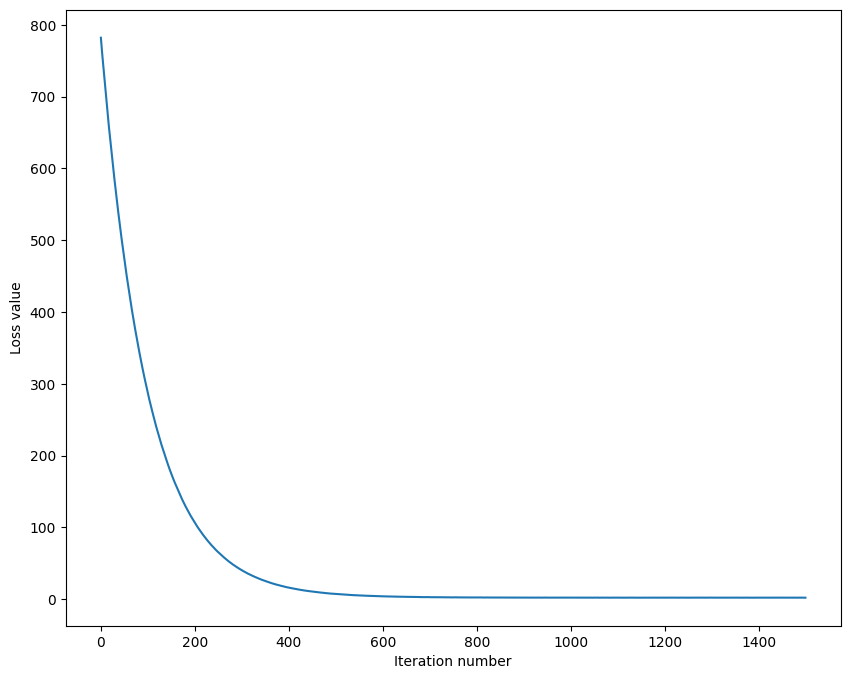

In [13]:
# A useful debugging strategy is to plot the loss as a function of
# iteration number:
plt.plot(loss_hist)
plt.xlabel('Iteration number')
plt.ylabel('Loss value')
plt.show()

In [14]:
# Write the LinearClassifier.predict function and evaluate the performance on
# both the training and validation set
# You should get validation accuracy of about 0.34 (> 0.33).
y_train_pred = softmax.predict(X_train)
print('training accuracy: %f' % (np.mean(y_train == y_train_pred), ))
y_val_pred = softmax.predict(X_val)
print('validation accuracy: %f' % (np.mean(y_val == y_val_pred), ))

training accuracy: 0.330551
validation accuracy: 0.346000


In [15]:
# Save the trained model for autograder.
softmax.save("softmax.npy")

softmax.npy saved.


In [23]:
# Use the validation set to tune hyperparameters (regularization strength and
# learning rate). You should experiment with different ranges for the learning
# rates and regularization strengths; if you are careful you should be able to
# get a classification accuracy of about 0.365 (> 0.36) on the validation set.

# Note: you may see runtime/overflow warnings during hyper-parameter search.
# This may be caused by extreme values, and is not a bug.

# results is dictionary mapping tuples of the form
# (learning_rate, regularization_strength) to tuples of the form
# (training_accuracy, validation_accuracy). The accuracy is simply the fraction
# of data points that are correctly classified.
results = {}
best_val = -1   # The highest validation accuracy that we have seen so far.
best_softmax = None # The Softmax object that achieved the highest validation rate.

################################################################################
# TODO:                                                                        #
learning_rates = [1e-7,1e-6,1e-5]
regularization_strengths = [2.5e4, 1e4,2e4]
for lr in learning_rates:
    for reg in regularization_strengths:
        softmax=Softmax()
        softmax.train(X_train,y_train,lr,reg,1300)
        y_train_pred=softmax.predict(X_train)
        y_val_pred=softmax.predict(X_val)
        train_accuracy=np.sum(y_train_pred==y_train)/y_train.shape[0]
        val_accuracy=np.sum(y_val_pred==y_val)/y_val.shape[0]
        results[(lr, reg)]=(train_accuracy,val_accuracy)
        if val_accuracy>best_val:
            best_val=val_accuracy
            best_softmax=softmax
# Write code that chooses the best hyperparameters by tuning on the validation #
# set. For each combination of hyperparameters, train a Softmax on the.        #
# training set, compute its accuracy on the training and validation sets, and  #
# store these numbers in the results dictionary. In addition, store the best   #
# validation accuracy in best_val and the Softmax object that achieves this.   #
# accuracy in best_softmax.                                                    #
#                                                                              #
# Hint: You should use a small value for num_iters as you develop your         #
# validation code so that the classifiers don't take much time to train; once  #
# you are confident that your validation code works, you should rerun the      #
# code with a larger value for num_iters.                                      #
################################################################################

# Provided as a reference. You may or may not want to change these hyperparameters




# Print out results.
for lr, reg in sorted(results):
    train_accuracy, val_accuracy = results[(lr, reg)]
    print('lr %e reg %e train accuracy: %f val accuracy: %f' % (
                lr, reg, train_accuracy, val_accuracy))

print('best validation accuracy achieved during cross-validation: %f' % best_val)

lr 1.000000e-07 reg 1.000000e+04 train accuracy: 0.348469 val accuracy: 0.371000
lr 1.000000e-07 reg 2.000000e+04 train accuracy: 0.337245 val accuracy: 0.357000
lr 1.000000e-07 reg 2.500000e+04 train accuracy: 0.329224 val accuracy: 0.342000
lr 1.000000e-06 reg 1.000000e+04 train accuracy: 0.348408 val accuracy: 0.351000
lr 1.000000e-06 reg 2.000000e+04 train accuracy: 0.330551 val accuracy: 0.348000
lr 1.000000e-06 reg 2.500000e+04 train accuracy: 0.316898 val accuracy: 0.335000
lr 1.000000e-05 reg 1.000000e+04 train accuracy: 0.222571 val accuracy: 0.226000
lr 1.000000e-05 reg 2.000000e+04 train accuracy: 0.143796 val accuracy: 0.131000
lr 1.000000e-05 reg 2.500000e+04 train accuracy: 0.121102 val accuracy: 0.130000
best validation accuracy achieved during cross-validation: 0.371000


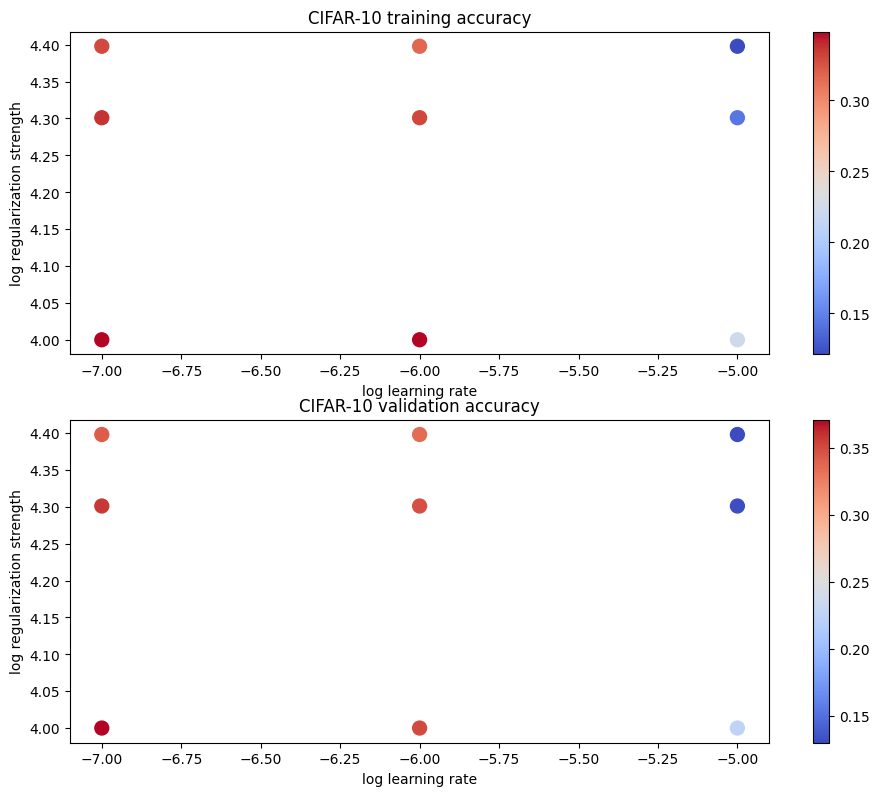

In [24]:
# Visualize the cross-validation results
import math
import pdb

# pdb.set_trace()

x_scatter = [math.log10(x[0]) for x in results]
y_scatter = [math.log10(x[1]) for x in results]

# plot training accuracy
marker_size = 100
colors = [results[x][0] for x in results]
plt.subplot(2, 1, 1)
plt.tight_layout(pad=3)
plt.scatter(x_scatter, y_scatter, marker_size, c=colors, cmap=plt.cm.coolwarm)
plt.colorbar()
plt.xlabel('log learning rate')
plt.ylabel('log regularization strength')
plt.title('CIFAR-10 training accuracy')

# plot validation accuracy
colors = [results[x][1] for x in results] # default size of markers is 20
plt.subplot(2, 1, 2)
plt.scatter(x_scatter, y_scatter, marker_size, c=colors, cmap=plt.cm.coolwarm)
plt.colorbar()
plt.xlabel('log learning rate')
plt.ylabel('log regularization strength')
plt.title('CIFAR-10 validation accuracy')
plt.show()

In [25]:
# Evaluate the best softmax on test set
y_test_pred = best_softmax.predict(X_test)
test_accuracy = np.mean(y_test == y_test_pred)
print('Softmax classifier on raw pixels final test set accuracy: %f' % test_accuracy)

Softmax classifier on raw pixels final test set accuracy: 0.360000


In [26]:
# Save best softmax model
best_softmax.save("best_softmax.npy")

best_softmax.npy saved.


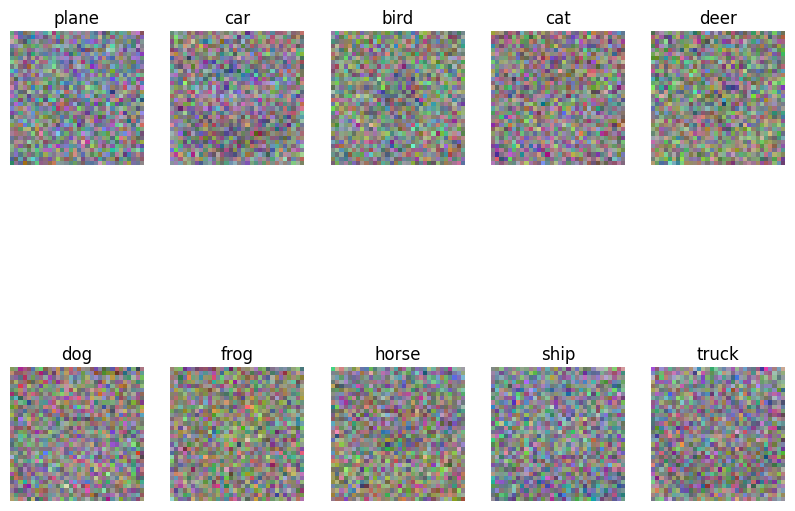

In [27]:
# Visualize the learned weights for each class.
# Depending on your choice of learning rate and regularization strength, these may
# or may not be nice to look at.
w = best_softmax.W[:-1,:] # strip out the bias
w = w.reshape(32, 32, 3, 10)
w_min, w_max = np.min(w), np.max(w)
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
for i in range(10):
    plt.subplot(2, 5, i + 1)

    # Rescale the weights to be between 0 and 255
    wimg = 255.0 * (w[:, :, :, i].squeeze() - w_min) / (w_max - w_min)
    plt.imshow(wimg.astype('uint8'))
    plt.axis('off')
    plt.title(classes[i])

**行内问题 3**

描述你可视化得到的 Softmax 分类器权重，并简要解释它们为什么呈现出这样的形态。

$\color{blue}{\textit{你的答案：}}$ *在此填写。*  


**行内问题 4**——*判断正误*

假设总体训练损失定义为所有训练样本逐样本损失之和。向训练集加入一个新样本，有可能改变 Softmax 损失，却不改变 SVM 损失。

$\color{blue}{\textit{你的答案：}}$


$\color{blue}{\textit{你的解释：}}$
